# 📔 **Resolución**
Una vez que la nota sea entregada, encontrarás la resolución en este link de notion:

https://www.notion.so/Resoluci-n-MMIA-9ac788237c7e44c1a4cb2f5595dac10c?source=copy_link

Recuerda que existen varias formar de solucionar las actividades propuestas en los laboratorios. Toma la resolución entregada como referencia. En caso de que el link de resolución no esté público, solicita acceso en el mismo link de notion.|

In [1]:
import sys
# Detectar si se está ejecutando en Google Colab
if 'google.colab' in sys.modules:
    print("Ejecutando en Google Colab. Instalando dependencias requeridas...")
    !pip install -q torchsummary pynvml nvidia-ml-py
else:
    print("Ejecutando en entorno local.")


Ejecutando en entorno local.


In [2]:
import sys
# Detectar si se está ejecutando en Google Colab
if 'google.colab' in sys.modules:
    print("Ejecutando en Google Colab. Instalando dependencias requeridas...")
    !pip install -q torchsummary pynvml nvidia-ml-py
else:
    print("Ejecutando en entorno local.")


Ejecutando en entorno local.


# El "Hello World" de las Redes Neuronales con PyTorch


El código proporcionado demuestra todo el proceso de creación de un modelo de regresión lineal simple, su entrenamiento, la realización de predicciones y la inspección de los parámetros del modelo. El conjunto de datos utilizado consiste en un conjunto de números x e y, donde x es `[-1.0, 0.0, 1.0, 2.0, 3.0, 4.0]` e y es `[-3.0, -1.0, 1.0, 3.0, 5.0, 7.0]`. El objetivo del modelo es aproximar la relación lineal `y = 2x - 1` basándose en estos datos de entrenamiento.



In [3]:
print("x es ", [-1.0, 0.0, 1.0, 2.0, 3.0, 4.0]) # entrada
print("y es ", [-3.0, -1.0, 1.0, 3.0, 5.0, 7.0]) # salida

x es  [-1.0, 0.0, 1.0, 2.0, 3.0, 4.0]
y es  [-3.0, -1.0, 1.0, 3.0, 5.0, 7.0]


Tenga en cuenta que con un enfoque basado en reglas, solo deberíamos escribir una función como esta


In [4]:
def function_with_rules(x):
    y = (2 * x) - 1
    return y

x = 4
print("Para x =", x, ", y = ", function_with_rules(x=x))

Para x = 4 , y =  7


## Importación de Librerías

Importamos las librerías necesarias, incluyendo PyTorch para construir y entrenar el modelo de red neuronal y NumPy para manejar datos numéricos.


In [5]:
import torch
import torch.nn as nn # redes neuronales
import torch.optim as optim #
import numpy as np
import os

C:\Users\Usuario\anaconda3\envs\data_science\Lib\site-packages\torch\cuda\__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


# Verificación de disponibilidad de GPU

Esta línea de código inicializa un dispositivo PyTorch en función de si CUDA, la librería de aceleración por GPU para GPUs de NVIDIA, está disponible en el sistema o no. Por lo tanto, la línea de código establece esencialmente la variable device en "cuda" si CUDA está disponible, lo que indica que se puede utilizar la aceleración por GPU, y "cpu" en caso contrario, indicando que los cálculos deben realizarse en la CPU. Este enfoque permite alternar sin problemas entre los cálculos en CPU y GPU según la disponibilidad, garantizando que el código se ejecute en el mejor hardware disponible sin errores.


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Está utilizando el dispositivo:", device)

Está utilizando el dispositivo: cpu


## Inspección del estado de la GPU en Google Colab
Cuando ejecuta !nvidia-smi, se muestra información sobre la GPU de Nvidia asignada a su sesión de Colab, incluidos detalles como el modelo de GPU, el uso de memoria de la GPU, los procesos que se ejecutan actualmente en la GPU y más. Este comando es útil para verificar que tiene acceso a una GPU y para monitorear su uso durante las tareas de entrenamiento o inferencia en Colab.


In [7]:
import subprocess
import torch
if torch.cuda.is_available():
    try:
        print(subprocess.check_output("nvidia-smi", shell=True, text=True))
    except Exception:
        print("nvidia-smi no está disponible en el PATH del sistema.")
else:
    print("GPU no disponible en este entorno.")


GPU no disponible en este entorno.


El comando `nvidia-smi -L` enumera las GPUs disponibles en el sistema.


In [8]:
import subprocess
import torch
if torch.cuda.is_available():
    try:
        print(subprocess.check_output("nvidia-smi -L", shell=True, text=True))
    except Exception:
        print("nvidia-smi no está disponible en el PATH del sistema.")
else:
    print("GPU no disponible en este entorno.")


GPU no disponible en este entorno.


El comando `nvidia-smi -L | wc -l` se utiliza para contar el número de GPUs disponibles en una máquina.



In [9]:
import subprocess
import torch
if torch.cuda.is_available():
    try:
        out = subprocess.check_output("nvidia-smi -L", shell=True, text=True)
        print("Número de GPUs:", len(out.strip().split('\n')))
    except Exception:
        print("nvidia-smi no está disponible en el PATH del sistema.")
else:
    print("Número de GPUs disponibles: 0")


Número de GPUs disponibles: 0


## Control de la asignación de GPU con la configuración CUDA_VISIBLE_DEVICES
Este fragmento de código establece la variable de entorno CUDA_VISIBLE_DEVICES, que utiliza CUDA (la plataforma de computación paralela de NVIDIA) para especificar qué GPUs deben hacerse visibles para las aplicaciones habilitadas para CUDA.

Establecer CUDA_VISIBLE_DEVICES es útil cuando tiene varias GPUs disponibles pero solo desea utilizar un subconjunto de ellas para una tarea específica. Al configurar esta variable de entorno, puede controlar qué GPUs son utilizadas por las aplicaciones habilitadas para CUDA, como los marcos de aprendizaje profundo TensorFlow o PyTorch.




In [10]:
num_gpus = 1 # num. gpus you want to use in this notebook

os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(str(x) for x in range(num_gpus))

print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])

CUDA_VISIBLE_DEVICES = 0


## Función para seleccionar el mejor dispositivo CUDA


Esta función `get_best_cuda_device` ayuda a seleccionar automáticamente el dispositivo GPU habilitado para CUDA más adecuado para los cálculos de PyTorch. Comprueba la disponibilidad de CUDA y, si hay varias GPUs presentes, identifica la que tiene más memoria libre para optimizar el rendimiento y evitar errores de falta de memoria (out-of-memory). Si no hay ningún dispositivo CUDA disponible, utiliza la CPU por defecto.


In [11]:
# This code is courtesy of Slin Castro (MMIA 3era Cohorte)
import torch

def get_best_cuda_device():
    if not torch.cuda.is_available():
        print("CUDA no está disponible. Usando CPU.")
        return torch.device("cpu")

    try:
        import pynvml
        pynvml.nvmlInit()
        best_gpu = 0
        max_free_mem = 0

        for i in range(torch.cuda.device_count()):
            handle = pynvml.nvmlDeviceGetHandleByIndex(i)
            mem_info = pynvml.nvmlDeviceGetMemoryInfo(handle)
            free_mem = mem_info.free
            print(f"GPU {i} - Memoria libre: {free_mem / 1024**2:.2f} MiB")

            if free_mem > max_free_mem:
                best_gpu = i
                max_free_mem = free_mem

        pynvml.nvmlShutdown()
        print(f"Seleccionando GPU {best_gpu} con más memoria libre.")
        return torch.device(f"cuda:{best_gpu}")
    except Exception as e:
        print("No se pudo inicializar pynvml para buscar la GPU con más memoria libre. Usando la GPU por defecto (cuda:0).")
        return torch.device("cuda:0")

get_best_cuda_device()


CUDA no está disponible. Usando CPU.


device(type='cpu')

# Definición del Modelo
Definimos un modelo de regresión lineal simple utilizando el contenedor `nn.Sequential` de PyTorch. Dentro del contenedor, tenemos una capa `nn.Linear`, que representa una transformación lineal.


In [12]:
# Construir un modelo secuencial simple
model = nn.Sequential(
    nn.Linear(1, 1) # theta'*x, logits
    #no activation, identity
) #model loaded into the RAM

model.to(device)# Mover el modelo a la GPU si está disponible

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
)

Este código define un modelo de red neuronal simple utilizando el contenedor `nn.Sequential` de PyTorch, que es una forma conveniente de crear una secuencia de capas de redes neuronales. En este caso, solo tenemos una capa:

* `nn.Linear(1, 1)`: Esta línea define una capa lineal (completamente conectada) dentro del modelo. Desglosemos los argumentos:

    * `nn.Linear`: Esta es la clase de capa lineal proporcionada por PyTorch, que implementa una transformación lineal. Es esencialmente una operación de multiplicación de matrices.

    * `1, 1`: El primer 1 representa el número de características de entrada, y el segundo 1 representa el número de características de salida. En otras palabras, esta capa tiene una característica de entrada y produce una característica de salida.

Entonces, ¿qué hace esta capa? Es una transformación lineal que se puede expresar como $y=\theta_0+\theta_1x$, donde:

* $y$ es la salida (un solo número en este caso).
* $\theta_1$ es el peso (un parámetro aprendible), y dado que es de 1x1, es un escalar.
* $x$ es la característica de entrada (un solo número en este caso).
* $\theta_0$ es el sesgo (otro parámetro aprendible), también un escalar.

Esta capa lineal esencialmente intenta aprender los mejores valores para $\theta_0$ y $\theta_1$ que permitan al modelo realizar predicciones basadas en la característica de entrada $x$.

En el contexto de este problema de regresión lineal (predicción de y basada en x), esta capa lineal modela una relación lineal entre x e y. Es el núcleo de este modelo, y su objetivo durante el entrenamiento es ajustar los pesos $\theta_0$ y $\theta_1$ para minimizar el error cuadrático medio (MSE) entre los valores predichos y los valores objetivo reales.

El método `.to(device)` en PyTorch se utiliza para mover tensores o modelos a un dispositivo específico, como una GPU o una CPU. Este método se usa comúnmente para garantizar que los tensores y modelos sean compatibles con el dispositivo en el que se realizan los cálculos.

Cuando llama a .to(device), especifica el dispositivo como argumento. Por ejemplo, si desea mover un tensor o modelo a la GPU (si está disponible), utiliza torch.device("cuda"). Si desea utilizar la CPU, especifica torch.device("cpu").


## Visualización del modelo



In [13]:
from torchsummary import summary
features = 1 # our input is a single feature
summary(model, input_size=(features,)) # salida shape [-1,1], -1 is the batch dim

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 1]               2
Total params: 2
Trainable params: 2
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


El fragmento de código proporcionado utiliza la función summary de la librería `torchsummary` para generar un resumen del modelo, incluyendo información sobre las capas y sus formas de salida.

Aquí hay un desglose de cada parte del código:

`from torchsummary import summary:` Esta línea importa la función summary de la librería `torchsummary`. Esta función proporciona un resumen de un modelo PyTorch, incluyendo detalles como el número de parámetros y las formas de salida de cada capa.

`features = 1:` Esta línea define el número de características en los datos de entrada. En este caso, indica que la entrada al modelo consiste en una sola característica. Esta información se utiliza para especificar el tamaño de entrada al generar el resumen del modelo.

`summary(model, input_size=(features,)):` Esta línea llama a la función summary, pasando el modelo y el tamaño de entrada como argumentos. El parámetro input_size especifica el tamaño de los datos de entrada esperados por el modelo. En este caso, se especifica como una tupla `(features,)`, lo que indica que los datos de entrada consisten en una sola característica. Luego, la función summary analiza el modelo y genera un resumen, que incluye detalles como los tipos de capas, las formas de salida y el número de parámetros en cada capa.

La forma de salida [-1,1] indica que la salida del modelo tiene una dimensión de lote (-1) y una sola dimensión de característica (1). El -1 en la dimensión del lote representa que el tamaño del lote puede variar y se determina dinámicamente en función de los datos de entrada durante la inferencia o el entrenamiento.


# Función de Pérdida y Optimizador

Definimos la función de pérdida como el Error Cuadrático Medio (MSE) usando `nn.MSELoss`. Esta es una función de pérdida común para problemas de regresión.
Luego configuramos el optimizador como Descenso de Gradiente Estocástico (SGD) usando `optim.SGD`. Se utiliza para actualizar los parámetros del modelo durante el entrenamiento.


In [14]:
# Define the loss function and optimizer
criterion = nn.MSELoss() #evaluation, loss function J
optimizer = optim.SGD(model.parameters(), lr=0.01)


 Desglosemos el código donde se definen la función de pérdida y el optimizador:

* `criterion = nn.MSELoss()`: Aquí definimos la función de pérdida como el Error Cuadrático Medio (MSE) usando `nn.MSELoss()`. La pérdida `MSELoss` mide la diferencia cuadrática media entre los valores predichos y los valores objetivo reales. En el contexto de la regresión lineal, cuantifica qué tan bien coinciden las predicciones del modelo con los valores objetivo verdaderos. El objetivo durante el entrenamiento es minimizar esta pérdida, lo que significa que el modelo busca hacer que sus predicciones sean lo más cercanas posible a los objetivos reales.

* `optimizer = optim.SGD(model.parameters(), lr=0.01)`: Definimos el optimizador como Descenso de Gradiente Estocástico (SGD) usando `optim.SGD`. Los parámetros de este optimizador son los siguientes:
    * `model.parameters()`: Este método recupera todos los parámetros aprendibles del modelo. En el contexto del modelo de regresión lineal, estos parámetros son los pesos $\theta_0$ y $\theta_1$ de la capa lineal definida anteriormente. El optimizador ajustará estos parámetros durante el entrenamiento para minimizar la pérdida.
    * `lr=0.01`: Esto establece la tasa de aprendizaje para el optimizador. La tasa de aprendizaje es un hiperparámetro que controla el tamaño del paso durante el proceso de optimización. Influye en qué tan rápido o lento se actualizan los parámetros del modelo. Una tasa de aprendizaje más pequeña hace que el entrenamiento sea más estable pero puede requerir más épocas para converger, mientras que una tasa de aprendizaje más grande puede acelerar la convergencia pero puede llevar a sobrepasar los parámetros óptimos.



# Preparación de Datos

Definimos nuestros datos de entrada `xs` y datos de salida `ys` como arreglos NumPy. `xs` contiene los valores de entrada, y `ys` contiene los valores objetivo correspondientes.

Convertimos estos arreglos de NumPy en tensores de PyTorch y les cambiamos la forma usando `.view` para asegurarnos de que tengan la forma correcta para PyTorch.

`.view(-1, 1)` se utiliza para cambiar la forma de los tensores. El -1 en el método view indica que el tamaño de esa dimensión se infiere de la longitud de los datos en el tensor, y 1 especifica la nueva forma. En este caso, cambia la forma de los tensores para tener dimensiones `(6, 1)`, donde 6 representa el número de puntos de datos y 1 representa que hay una característica para cada punto de datos.


In [15]:
# Declarar entradas y salidas del modelo para entrenar y = 2x - 1
xs = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0], dtype=np.float32)
ys = np.array([-3.0, -1.0, 1.0, 3.0, 5.0, 7.0], dtype=np.float32)

print(xs.shape)

# Convertir arreglos NumPy en tensores PyTorch, cambiar su forma y mover a GPU si está disponible
xs = torch.tensor(xs).view(-1, 1).to(device)
ys = torch.tensor(ys).view(-1, 1).to(device)

print(xs.shape)

(6,)
torch.Size([6, 1])


Este código prepara los datos para entrenar un modelo usando PyTorch mediante la creación de un conjunto de datos (dataset) y un cargador de datos (dataloader). El conjunto de datos contiene pares de entrada-salida (`xs` y `ys`), y el cargador de datos proporcionará lotes (batches) de estos datos para el entrenamiento, donde cada lote contiene un número específico de muestras (`batch_size`) y se mezcla para cada época (`shuffle=True`).


Desglosemos lo que hace cada parte del código:

1. `from torch.utils.data import TensorDataset, DataLoader`: Esta línea importa la clase `TensorDataset` y la clase `DataLoader` del módulo `torch.utils.data`. Estas clases se usan comúnmente en PyTorch para manejar conjuntos de datos y la carga de datos durante el proceso de entrenamiento.

2. `dataset = TensorDataset(xs, ys)`: Esta línea crea un objeto de conjunto de datos utilizando la clase `TensorDataset`. `xs` y `ys` son tensores que contienen datos de entrada y etiquetas correspondientes, respectivamente. La clase `TensorDataset` permite combinar estos pares de entrada-salida en un solo objeto de conjunto de datos.

3. `dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)`: Esta línea crea un objeto de cargador de datos utilizando la clase `DataLoader`. Toma el objeto del conjunto de datos creado anteriormente (`dataset`) y parámetros adicionales como `batch_size` y `shuffle`. Aquí, `batch_size` especifica el número de muestras por lote, y `shuffle=True` indica que los datos se mezclarán aleatoriamente antes de dividirse en lotes. El cargador de datos luego iterará sobre estos lotes durante el proceso de entrenamiento.


In [16]:
from torch.utils.data import TensorDataset, DataLoader
# Definir el tamaño del lote
batch_size = 2

# Crear el conjunto de datos
dataset = TensorDataset(xs, ys)
print("xs: ", dataset.tensors[0], "\nys: ", dataset.tensors[1])

#reproducibility
torch.manual_seed(42)

# Crear el cargador de datos
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

xs:  tensor([[-1.],
        [ 0.],
        [ 1.],
        [ 2.],
        [ 3.],
        [ 4.]]) 
ys:  tensor([[-3.],
        [-1.],
        [ 1.],
        [ 3.],
        [ 5.],
        [ 7.]])


# Ejemplo de Diferenciación Automática en PyTorch

Este código demuestra un concepto fundamental en PyTorch: la diferenciación automática utilizando el método `.backward()`. Muestra cómo definir una función matemática simple, marcar un tensor para el cual se desean calcular los gradientes y luego calcular automáticamente la derivada de la función con respecto a ese tensor. Este es el mecanismo central que permite entrenar redes neuronales al calcular los gradientes de la función de pérdida con respecto a los parámetros del modelo.


Iniciando búsqueda detallada de N óptimo con múltiples inicializaciones...

Evaluando N = 2:


  -> MSE promedio: 0.171998 | Predicción promedio para 2.5: 5.8972 ± 0.2203 | Diferencia promedio: 0.3528

Evaluando N = 4:


  -> MSE promedio: 0.000411 | Predicción promedio para 2.5: 6.0668 ± 0.0929 | Diferencia promedio: 0.1832

Evaluando N = 8:


  -> MSE promedio: 0.001027 | Predicción promedio para 2.5: 6.0700 ± 0.0744 | Diferencia promedio: 0.1800

Evaluando N = 12:


  -> MSE promedio: 0.000678 | Predicción promedio para 2.5: 6.1571 ± 0.0302 | Diferencia promedio: 0.0929

Evaluando N = 16:


  -> MSE promedio: 0.001054 | Predicción promedio para 2.5: 6.1709 ± 0.0080 | Diferencia promedio: 0.0791

Evaluando N = 24:


  -> MSE promedio: 0.002179 | Predicción promedio para 2.5: 6.1955 ± 0.0130 | Diferencia promedio: 0.0545

Evaluando N = 32:


  -> MSE promedio: 0.008514 | Predicción promedio para 2.5: 6.1960 ± 0.0049 | Diferencia promedio: 0.0540

Evaluando N = 48:


  -> MSE promedio: 0.010527 | Predicción promedio para 2.5: 6.1883 ± 0.0033 | Diferencia promedio: 0.0617

Evaluando N = 64:


  -> MSE promedio: 0.007954 | Predicción promedio para 2.5: 6.1980 ± 0.0044 | Diferencia promedio: 0.0520

--- Análisis de Resultados ---
El valor óptimo es N = 64 con una diferencia promedio de 0.0520 y un MSE promedio de 0.007954.


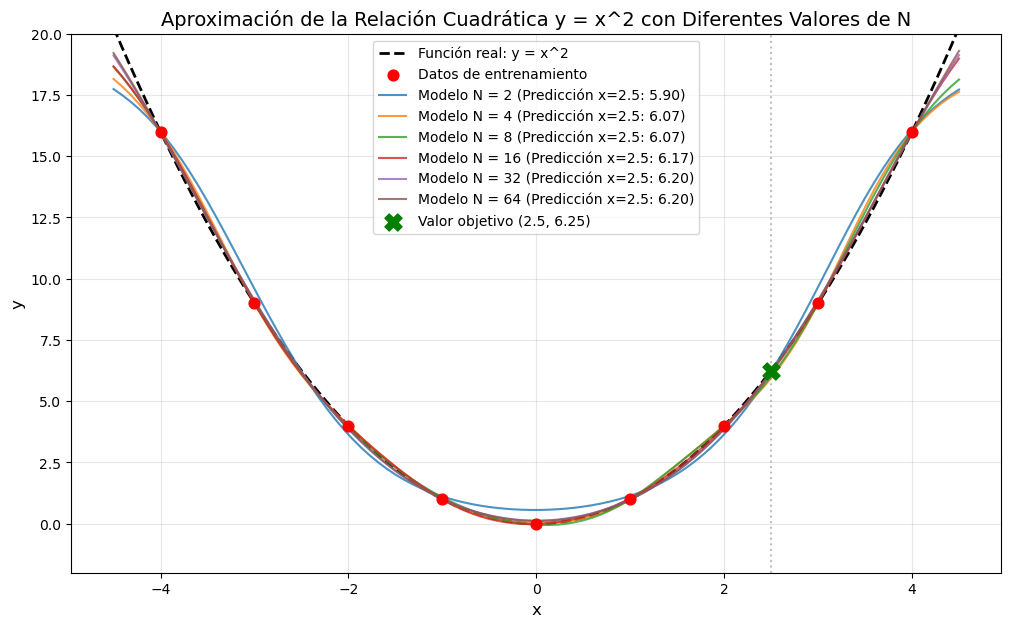

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Datos de entrenamiento para aproximar y = x^2
xs = np.array([-4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0], dtype=np.float32)
ys = np.array([16.0, 9.0, 4.0, 1.0, 0.0, 1.0, 4.0, 9.0, 16.0], dtype=np.float32)

xs_t = torch.tensor(xs).view(-1, 1).to(device)
ys_t = torch.tensor(ys).view(-1, 1).to(device)

# Búsqueda detallada y explícita de N óptimo con múltiples corridas para evaluar robustez
candidate_Ns = [2, 4, 8, 12, 16, 24, 32, 48, 64]
runs_per_N = 3
epochs = 10000

results = {}
curves_to_plot = {}

print("Iniciando búsqueda detallada de N óptimo con múltiples inicializaciones...")
for N in candidate_Ns:
    mse_list = []
    pred_list = []
    diff_list = []
    
    print(f"\nEvaluando N = {N}:")
    for run in range(runs_per_N):
        # Diferente semilla para evaluar varianza del entrenamiento
        torch.manual_seed(run * 100)
        
        # Red neuronal de 2 capas ocultas con N neuronas y activación sigmoide
        model = nn.Sequential(
            nn.Linear(1, N),
            nn.Sigmoid(),
            nn.Linear(N, N),
            nn.Sigmoid(),
            nn.Linear(N, 1)
        ).to(device)
        
        criterion = nn.MSELoss()
        optimizer = optim.SGD(model.parameters(), lr=0.01)
        
        # Entrenamiento
        for epoch in range(epochs):
            optimizer.zero_grad()
            outputs = model(xs_t)
            loss = criterion(outputs, ys_t)
            loss.backward()
            optimizer.step()
            
        # Evaluación
        model.eval()
        with torch.no_grad():
            pred_val = model(torch.tensor([[2.5]]).to(device)).item()
            
        final_loss = loss.item()
        diff = abs(pred_val - 6.25)
        
        mse_list.append(final_loss)
        pred_list.append(pred_val)
        diff_list.append(diff)
        
    mean_mse = np.mean(mse_list)
    mean_pred = np.mean(pred_list)
    std_pred = np.std(pred_list)
    mean_diff = np.mean(diff_list)
    
    results[N] = {
        'mean_mse': mean_mse,
        'mean_pred': mean_pred,
        'std_pred': std_pred,
        'mean_diff': mean_diff
    }
    print(f"  -> MSE promedio: {mean_mse:.6f} | Predicción promedio para 2.5: {mean_pred:.4f} ± {std_pred:.4f} | Diferencia promedio: {mean_diff:.4f}")
    
    # Generar curva ajustada para visualización
    x_grid = np.linspace(-4.5, 4.5, 100, dtype=np.float32)
    x_grid_t = torch.tensor(x_grid).view(-1, 1).to(device)
    with torch.no_grad():
        y_grid = model(x_grid_t).cpu().numpy().flatten()
    curves_to_plot[N] = y_grid

# Seleccionar e imprimir el mejor modelo
best_N = min(results, key=lambda k: results[k]['mean_diff'])
print(f"\n--- Análisis de Resultados ---")
print(f"El valor óptimo es N = {best_N} con una diferencia promedio de {results[best_N]['mean_diff']:.4f} y un MSE promedio de {results[best_N]['mean_mse']:.6f}.")

# Graficar comparación de aproximaciones frente a la función real y = x^2
plt.figure(figsize=(12, 7))
x_dense = np.linspace(-4.5, 4.5, 100)
y_true = x_dense ** 2

plt.plot(x_dense, y_true, 'k--', label="Función real: y = x^2", linewidth=2)
plt.scatter(xs, ys, color='red', s=60, zorder=5, label="Datos de entrenamiento")

# Graficar curvas predichas de modelos representativos
for N in [2, 4, 8, 16, 32, 64]:
    if N in curves_to_plot:
        plt.plot(x_dense, curves_to_plot[N], label=f"Modelo N = {N} (Predicción x=2.5: {results[N]['mean_pred']:.2f})", alpha=0.8)

# Resaltar la predicción para x = 2.5 y el valor real objetivo (2.5, 6.25)
plt.axvline(x=2.5, color='gray', linestyle=':', alpha=0.5)
plt.scatter([2.5], [6.25], color='green', marker='X', s=150, zorder=6, label="Valor objetivo (2.5, 6.25)")

plt.title("Aproximación de la Relación Cuadrática y = x^2 con Diferentes Valores de N", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper center')
plt.ylim(-2, 20)
plt.show()


#**Entrenamiento**

Este código representa un ciclo de entrenamiento típico para un modelo de red neuronal en PyTorch. Desglosemos paso a paso:

1. **Inicialización del bucle de entrenamiento**: Establece el número de épocas (`num_epochs`) a 500, indicando cuántas veces se pasará el conjunto de datos completo hacia adelante (forward) y hacia atrás (backward) a través de la red neuronal.

2. **Bucle sobre las épocas**: El bucle externo itera sobre cada época desde 0 hasta `num_epochs - 1`. Durante cada época, todo el conjunto de datos pasa a través de la red una vez.

3. **Bucle interno sobre los lotes**: El bucle interno itera sobre los lotes de datos (`xs_batch` y `y_batch`) obtenidos del `dataloader`. `xs_batch` contiene muestras de datos de entrada, y `y_batch` contiene las etiquetas correspondientes.

4. **Paso hacia adelante (Forward Pass)**: Dentro del bucle interno, el lote de entrada (`xs_batch`) se alimenta al modelo de red neuronal (`model`) para obtener predicciones (`outputs`).

5. **Calcular la Pérdida**: Las salidas predichas (`outputs`) se comparan con las etiquetas reales (`y_batch`) utilizando una función de pérdida (`criterion`) para calcular el valor de la pérdida (`loss`). La pérdida cuantifica qué tan bien coinciden las predicciones del modelo con las etiquetas verdaderas.

6. **Retropropagación y actualización de parámetros**: Limpiamos los gradientes usando `optimizer.zero_grad()` para prepararnos para un nuevo paso hacia atrás. Esto es esencial para evitar la acumulación de gradientes de un lote a otro, lo que podría llevar a un entrenamiento incorrecto e inestable. Es una práctica estándar al entrenar redes neuronales con algoritmos de optimización basados en gradientes como el descenso de gradiente estocástico (SGD).
Después de calcular la pérdida, se calculan los gradientes de los parámetros del modelo con respecto a la pérdida (`loss.backward()`), y el optimizador actualiza los parámetros del modelo basándose en estos gradientes (`optimizer.step()`). Este proceso se llama retropropagación.




In [18]:
# Bucle de entrenamiento
num_epochs = 100
for epoch in range(num_epochs):

    for batch_idx, (xs_batch, y_batch) in enumerate(dataloader):

        #print("Batch", batch_idx, "xs_batch:", xs_batch, "\nys_batch:", y_batch)
        #print("***************")
        # Paso hacia adelante (Forward pass)
        outputs = model(xs_batch)

        # Calcular la pérdida
        loss = criterion(outputs, y_batch) #MSE

        # Limpiar gradientes, realizar paso hacia atrás y actualizar pesos
        optimizer.zero_grad()
        loss.backward() #backpropagation
        optimizer.step() #Gradiend descent

    print("======================, End of Epoch", epoch)
    if epoch % 2 == 0:
        print("At Epoch ", epoch, "Loss is", loss.item()) # Usar loss.item() para obtener un valor escalar



======================, End of Epoch 0
At Epoch  0 Loss is 4.356618881225586
======================, End of Epoch 1
======================, End of Epoch 2
At Epoch  2 Loss is 3.1049325466156006
======================, End of Epoch 3
======================, End of Epoch 4
At Epoch  4 Loss is 4.8524909019470215
======================, End of Epoch 5
======================, End of Epoch 6
At Epoch  6 Loss is 8.32615852355957
======================, End of Epoch 7
======================, End of Epoch 8
At Epoch  8 Loss is 3.142127275466919
======================, End of Epoch 9
======================, End of Epoch 10
At Epoch  10 Loss is 2.4473533630371094
======================, End of Epoch 11
======================, End of Epoch 12
At Epoch  12 Loss is 3.0085384845733643
======================, End of Epoch 13
======================, End of Epoch 14
At Epoch  14 Loss is 3.0106749534606934
======================, End of Epoch 15
======================, End of Epoch 16
At Epoch  16 Loss i

======================, End of Epoch 75
======================, End of Epoch 76
At Epoch  76 Loss is 0.10980086773633957
======================, End of Epoch 77
======================, End of Epoch 78
At Epoch  78 Loss is 0.33586007356643677
======================, End of Epoch 79
======================, End of Epoch 80
At Epoch  80 Loss is 0.2973800301551819
======================, End of Epoch 81
======================, End of Epoch 82
At Epoch  82 Loss is 0.09081870317459106
======================, End of Epoch 83
======================, End of Epoch 84
At Epoch  84 Loss is 0.2930867671966553
======================, End of Epoch 85
======================, End of Epoch 86
At Epoch  86 Loss is 0.1529729813337326
======================, End of Epoch 87
======================, End of Epoch 88
At Epoch  88 Loss is 0.1441144496202469
======================, End of Epoch 89
======================, End of Epoch 90
At Epoch  90 Loss is 0.22673086822032928
======================, End of Epoch

# Realizar una Predicción:
Después del entrenamiento, realizamos una predicción para el valor de entrada 10.0 pasándolo a través del modelo entrenado y convirtiendo el resultado en un escalar de Python usando `.item()`. La instrucción `with torch.no_grad()` deshabilita el cálculo de gradientes para las operaciones dentro del bloque `with`. El cálculo del gradiente se usa durante el entrenamiento para actualizar los parámetros del modelo. Sin embargo, al realizar predicciones, no necesitamos calcular gradientes.

Olvidar configurar el modelo de PyTorch en modo de evaluación (`model.eval()`) antes de realizar la inferencia puede provocar un comportamiento inesperado, particularmente con capas como Batch Normalization o Dropout, que se comportan de manera diferente durante el entrenamiento y la inferencia. Esto puede dar como resultado predicciones incorrectas o un rendimiento degradado del modelo debido a una normalización o dropout inadecuados. La mejor práctica es configurar siempre el modelo en modo de evaluación antes de la inferencia para garantizar un comportamiento consistente y predicciones precisas.


In [19]:
# Realizar una predicción
model.eval()
with torch.no_grad():
    predicted_value = model(torch.tensor([10.0]).to(device)) # forward!! h(x)

print(predicted_value)
print(predicted_value.item())  # Convertir el resultado en un escalar de Python

#y = 2*x - 1 para x = 10: y:19

tensor([13.0603])
13.060269355773926


# Imprimir los Parámetros del Modelo
Finalmente, imprimimos los nombres de los parámetros del modelo y sus valores. Incase, solo hay un conjunto de parámetros que corresponden a la transformación lineal.


In [20]:
# Imprimir información de las capas del modelo
for name, param in model.named_parameters():
    print(name)
    print(param.data)# print(param.data.item())
    #print(param.grad)
print(model)

# y = 2*x -1 = theta_0 + theta_1*x

0.weight
tensor([[ 0.4307],
        [ 0.0230],
        [ 0.6773],
        [-0.1405],
        [-0.2880],
        [ 1.0329],
        [ 0.4187],
        [ 0.6364],
        [ 0.6487],
        [-0.6818],
        [ 0.5084],
        [ 0.5748],
        [-0.2770],
        [ 0.4294],
        [ 0.5032],
        [-0.7763],
        [ 0.1161],
        [ 1.0364],
        [-0.3668],
        [ 0.4385],
        [-0.6221],
        [ 0.6982],
        [-0.2595],
        [-0.3359],
        [-0.5314],
        [ 0.4502],
        [ 0.3417],
        [ 0.6784],
        [ 0.4052],
        [ 0.1529],
        [-0.3595],
        [ 0.9451],
        [-0.4377],
        [ 0.2418],
        [-0.7853],
        [ 0.3541],
        [ 0.2106],
        [-0.0462],
        [ 0.3535],
        [ 0.6986],
        [ 0.0986],
        [ 0.3089],
        [ 0.6610],
        [-0.7647],
        [ 0.2906],
        [ 0.3878],
        [-0.6612],
        [-0.1798],
        [-0.5630],
        [-0.3752],
        [-0.4152],
        [ 0.3358],
   

# Actividad



Para los datos dados, construya una red neuronal con dos capas ocultas, cada una compuesta por 'N' unidades, y utilice la función de activación sigmoide. Elija el valor de 'N' de modo que la predicción para una entrada de 2.5 sea lo más cercana posible al valor esperado (considerando la relación cuadrática entre la entrada y la salida, es decir, $y = x^2$). La capa de salida debe tener una sola unidad con una función de activación lineal. Compile su modelo utilizando el mismo optimizador y función de pérdida que en el ejemplo anterior. Entrene su modelo durante 10000 épocas y calcule el error cuadrático medio (MSE) en el conjunto de datos de entrenamiento.


Iniciando búsqueda detallada de N óptimo con múltiples inicializaciones...

Evaluando N = 2:


  -> MSE promedio: 0.171998 | Predicción promedio para 2.5: 5.8972 ± 0.2203 | Diferencia promedio: 0.3528

Evaluando N = 4:


  -> MSE promedio: 0.000411 | Predicción promedio para 2.5: 6.0668 ± 0.0929 | Diferencia promedio: 0.1832

Evaluando N = 8:


  -> MSE promedio: 0.001027 | Predicción promedio para 2.5: 6.0700 ± 0.0744 | Diferencia promedio: 0.1800

Evaluando N = 12:


  -> MSE promedio: 0.000678 | Predicción promedio para 2.5: 6.1571 ± 0.0302 | Diferencia promedio: 0.0929

Evaluando N = 16:


  -> MSE promedio: 0.001054 | Predicción promedio para 2.5: 6.1709 ± 0.0080 | Diferencia promedio: 0.0791

Evaluando N = 24:


  -> MSE promedio: 0.002179 | Predicción promedio para 2.5: 6.1955 ± 0.0130 | Diferencia promedio: 0.0545

Evaluando N = 32:


  -> MSE promedio: 0.008514 | Predicción promedio para 2.5: 6.1960 ± 0.0049 | Diferencia promedio: 0.0540

Evaluando N = 48:


  -> MSE promedio: 0.010527 | Predicción promedio para 2.5: 6.1883 ± 0.0033 | Diferencia promedio: 0.0617

Evaluando N = 64:


  -> MSE promedio: 0.007954 | Predicción promedio para 2.5: 6.1980 ± 0.0044 | Diferencia promedio: 0.0520

--- Análisis de Resultados ---
El valor óptimo es N = 64 con una diferencia promedio de 0.0520 y un MSE promedio de 0.007954.


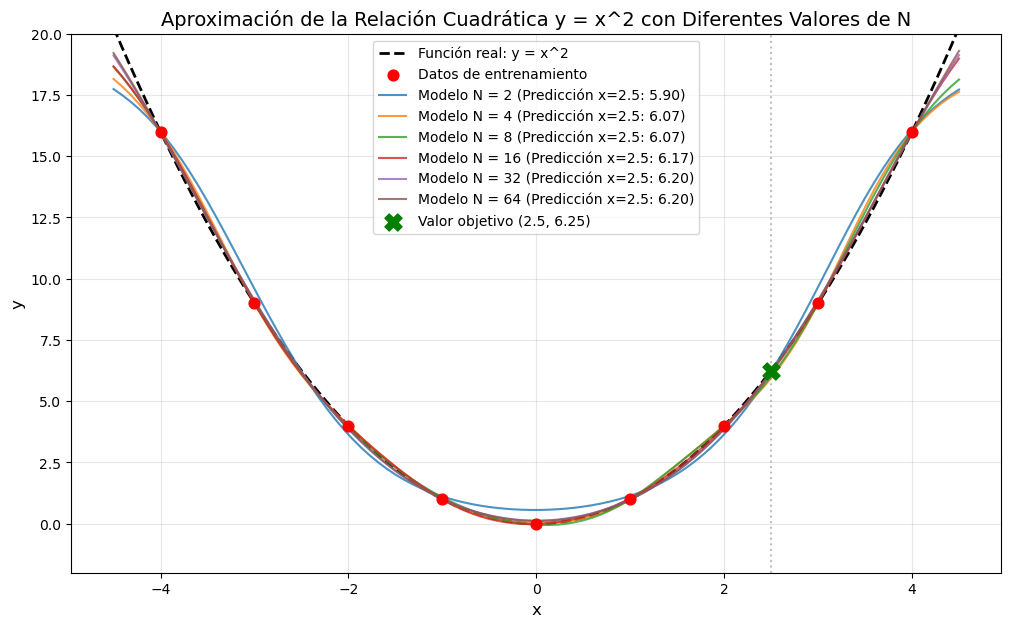

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Datos de entrenamiento para aproximar y = x^2
xs = np.array([-4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0], dtype=np.float32)
ys = np.array([16.0, 9.0, 4.0, 1.0, 0.0, 1.0, 4.0, 9.0, 16.0], dtype=np.float32)

xs_t = torch.tensor(xs).view(-1, 1).to(device)
ys_t = torch.tensor(ys).view(-1, 1).to(device)

# Búsqueda detallada y explícita de N óptimo con múltiples corridas para evaluar robustez
candidate_Ns = [2, 4, 8, 12, 16, 24, 32, 48, 64]
runs_per_N = 3
epochs = 10000

results = {}
curves_to_plot = {}

print("Iniciando búsqueda detallada de N óptimo con múltiples inicializaciones...")
for N in candidate_Ns:
    mse_list = []
    pred_list = []
    diff_list = []
    
    print(f"\nEvaluando N = {N}:")
    for run in range(runs_per_N):
        # Diferente semilla para evaluar varianza del entrenamiento
        torch.manual_seed(run * 100)
        
        # Red neuronal de 2 capas ocultas con N neuronas y activación sigmoide
        model = nn.Sequential(
            nn.Linear(1, N),
            nn.Sigmoid(),
            nn.Linear(N, N),
            nn.Sigmoid(),
            nn.Linear(N, 1)
        ).to(device)
        
        criterion = nn.MSELoss()
        optimizer = optim.SGD(model.parameters(), lr=0.01)
        
        # Entrenamiento
        for epoch in range(epochs):
            optimizer.zero_grad()
            outputs = model(xs_t)
            loss = criterion(outputs, ys_t)
            loss.backward()
            optimizer.step()
            
        # Evaluación
        model.eval()
        with torch.no_grad():
            pred_val = model(torch.tensor([[2.5]]).to(device)).item()
            
        final_loss = loss.item()
        diff = abs(pred_val - 6.25)
        
        mse_list.append(final_loss)
        pred_list.append(pred_val)
        diff_list.append(diff)
        
    mean_mse = np.mean(mse_list)
    mean_pred = np.mean(pred_list)
    std_pred = np.std(pred_list)
    mean_diff = np.mean(diff_list)
    
    results[N] = {
        'mean_mse': mean_mse,
        'mean_pred': mean_pred,
        'std_pred': std_pred,
        'mean_diff': mean_diff
    }
    print(f"  -> MSE promedio: {mean_mse:.6f} | Predicción promedio para 2.5: {mean_pred:.4f} ± {std_pred:.4f} | Diferencia promedio: {mean_diff:.4f}")
    
    # Generar curva ajustada para visualización
    x_grid = np.linspace(-4.5, 4.5, 100, dtype=np.float32)
    x_grid_t = torch.tensor(x_grid).view(-1, 1).to(device)
    with torch.no_grad():
        y_grid = model(x_grid_t).cpu().numpy().flatten()
    curves_to_plot[N] = y_grid

# Seleccionar e imprimir el mejor modelo
best_N = min(results, key=lambda k: results[k]['mean_diff'])
print(f"\n--- Análisis de Resultados ---")
print(f"El valor óptimo es N = {best_N} con una diferencia promedio de {results[best_N]['mean_diff']:.4f} y un MSE promedio de {results[best_N]['mean_mse']:.6f}.")

# Graficar comparación de aproximaciones frente a la función real y = x^2
plt.figure(figsize=(12, 7))
x_dense = np.linspace(-4.5, 4.5, 100)
y_true = x_dense ** 2

plt.plot(x_dense, y_true, 'k--', label="Función real: y = x^2", linewidth=2)
plt.scatter(xs, ys, color='red', s=60, zorder=5, label="Datos de entrenamiento")

# Graficar curvas predichas de modelos representativos
for N in [2, 4, 8, 16, 32, 64]:
    if N in curves_to_plot:
        plt.plot(x_dense, curves_to_plot[N], label=f"Modelo N = {N} (Predicción x=2.5: {results[N]['mean_pred']:.2f})", alpha=0.8)

# Resaltar la predicción para x = 2.5 y el valor real objetivo (2.5, 6.25)
plt.axvline(x=2.5, color='gray', linestyle=':', alpha=0.5)
plt.scatter([2.5], [6.25], color='green', marker='X', s=150, zorder=6, label="Valor objetivo (2.5, 6.25)")

plt.title("Aproximación de la Relación Cuadrática y = x^2 con Diferentes Valores de N", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper center')
plt.ylim(-2, 20)
plt.show()


Este código está inspirado en el notebook "The Hello World of Neural Networks" de la Especialización de TensorFlow de Deeplearning.ai. Los conceptos e implementaciones se han adaptado para PyTorch.
